# **IMDB Sentiment Analysis Using LSTM**

# All Imports Here

In [90]:
import pandas as pd
import re
import nltk
import html
import torch.nn as nn
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from collections import Counter
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

# Download NLTK Tokenization and Stop Words

In [91]:
nltk.download('punkt_tab') # required for word tokenization
nltk.download('stopwords') # required for stop word list

[nltk_data] Downloading package punkt_tab to C:\Users\Ujjwal
[nltk_data]     Karki\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Ujjwal
[nltk_data]     Karki\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Import and View Data

Dataset: IMDB Movie Reviews dataset, containing review text and binary sentiment labels (`positive`/`negative`).


In [92]:
df = pd.read_csv("https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv")  # review, sentiment
print("Dataset: IMDB Movie Reviews")
print("Columns:", df.columns.tolist())
print("Raw dataframe shape:", df.shape)
df.head()


Dataset: IMDB Movie Reviews
Columns: ['review', 'sentiment']
Raw dataframe shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [93]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [94]:
# dataframe shape
df.shape

(50000, 2)

# Clean Missing and Duplicate Values

In [95]:
# checking duplicates and missing values
print(f'Missing values count: \n{df.isnull().sum()}\n')
print(f'Duplicates values count: {df.duplicated().sum()}')

Missing values count: 
review       0
sentiment    0
dtype: int64

Duplicates values count: 418


In [96]:
df = df.drop_duplicates()

In [97]:
print(f'Duplicates values count: {df.duplicated().sum()}')

Duplicates values count: 0


In [98]:
def clean(t):
  # replace https with " "
  t = re.sub(r"<[^>]*>", " ", t)
  t = re.sub(r"http\S+l@\w+", " ", t)
  t = re.sub(r"[^a-zA-Z\s]", " ", t)
  return t.lower()

In [99]:
df_clean = df.copy()
df_clean['review'] = df['review'].apply(clean)
df_clean.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming t...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there s a family where a little boy ...,negative
4,petter mattei s love in the time of money is...,positive


# Tokenization, Vocabulary, and Remove Stop Words

In [100]:
df_clean['review_tokenized'] = df_clean['review'].apply(word_tokenize)
df_clean.head()

,review,sentiment,review_tokenized
0,one of the other reviewers has mentioned that ...,positive,"[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production the filming t...,positive,"[a, wonderful, little, production, the, filmin..."
2,i thought this was a wonderful way to spend ti...,positive,"[i, thought, this, was, a, wonderful, way, to,..."
3,basically there s a family where a little boy ...,negative,"[basically, there, s, a, family, where, a, lit..."
4,petter mattei s love in the time of money is...,positive,"[petter, mattei, s, love, in, the, time, of, m..."


In [101]:
stop_words = set(stopwords.words('english'))
df_clean['review_tokenized'] = df_clean['review_tokenized'].apply(lambda x: [word for word in x if word not in stop_words])
df_clean.head()

,review,sentiment,review_tokenized
0,one of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, oz, epis..."
1,a wonderful little production the filming t...,positive,"[wonderful, little, production, filming, techn..."
2,i thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su..."
3,basically there s a family where a little boy ...,negative,"[basically, family, little, boy, jake, thinks,..."
4,petter mattei s love in the time of money is...,positive,"[petter, mattei, love, time, money, visually, ..."


In [102]:
counts = Counter(
    w
    for review in df_clean['review_tokenized'].dropna()
    for word in review
    for w in word.split()
)

print(counts.most_common(10))

[('movie', 87277), ('film', 79151), ('one', 53205), ('like', 39843), ('good', 29547), ('time', 24905), ('even', 24669), ('would', 24401), ('story', 22973), ('really', 22924)]


In [103]:
vocab = {"<pad>": 0, "<unk>": 1}
for w, _ in counts.most_common(10000):
  vocab[w] = len(vocab)

In [104]:
def encode(tokens, maxlen=200):
    ids = [vocab.get(word, vocab['<unk>']) for word in tokens][:maxlen]
    return ids + [vocab['<pad>']] * (maxlen - len(ids))

# Train, Test, and Split

In [105]:
X_train, X_test, y_train, y_test = train_test_split(df_clean['review_tokenized'], df_clean['sentiment'], test_size=0.2, random_state=42)

In [106]:
print(X_train.shape)

(39665,)


In [107]:
print(y_train.shape)

(39665,)


# Tensor Datasets and Dataset Loader

In [108]:
Xtr = torch.tensor(
    [encode(review) for review in X_train],
    dtype=torch.long
)
ytr = torch.tensor(
    y_train.map({"negative": 0, "positive": 1}).to_numpy(),
    dtype=torch.long
)

In [109]:
print(f'Xtr shape: {Xtr.shape}')
print(f'Ytr shape: {ytr.shape}')

Xtr shape: torch.Size([39665, 200])
Ytr shape: torch.Size([39665])


In [110]:
train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=128, shuffle=True, pin_memory=torch.cuda.is_available())

Xte = torch.tensor([encode(review) for review in X_test], dtype=torch.long)
yte = torch.tensor(y_test.map({"negative": 0, "positive": 1}).to_numpy(), dtype=torch.long)
test_loader = DataLoader(TensorDataset(Xte, yte), batch_size=256, shuffle=False, pin_memory=torch.cuda.is_available())

print(f"Xte shape: {Xte.shape}")
print(f"Yte shape: {yte.shape}")


Xte shape: torch.Size([9917, 200])
Yte shape: torch.Size([9917])


# Sentiment LSTM Model

In [111]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, emb=64, hidden=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb, padding_idx=vocab["<pad>"])
        self.lstm = nn.LSTM(
            emb,
            hidden,
            batch_first=True,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, 2)

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        last_forward = h_n[-2]
        last_backward = h_n[-1]
        h = torch.cat((last_forward, last_backward), dim=1)
        return self.fc(self.dropout(h))


In [112]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: not available; running on CPU")


Using: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [113]:
lstm = SentimentLSTM(len(vocab)).to(device)
optimizer = torch.optim.Adam(lstm.parameters(), weight_decay = 0.0001, lr=0.001)
loss_fn = nn.CrossEntropyLoss()

# Training (Epochs)

In [114]:
train_losses = []
train_accuracies = []
test_accuracies = []

epochs_to_train = 15

for epoch in range(epochs_to_train):
    lstm.train()

    epoch_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()
        pred = lstm(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item() * xb.size(0)
        correct_train += pred.argmax(dim=1).eq(yb).sum().item()
        total_train += yb.size(0)

    avg_epoch_loss = epoch_train_loss / total_train
    epoch_train_acc = correct_train / total_train

    lstm.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            pred = lstm(xb)
            correct_test += pred.argmax(dim=1).eq(yb).sum().item()
            total_test += yb.size(0)

    epoch_test_acc = correct_test / total_test

    train_losses.append(avg_epoch_loss)
    train_accuracies.append(epoch_train_acc)
    test_accuracies.append(epoch_test_acc)

    print(
        f"Epoch {epoch + 1}, "
        f"Loss: {avg_epoch_loss:.4f}, "
        f"Train Accuracy: {epoch_train_acc:.4f}, "
        f"Test Accuracy: {epoch_test_acc:.4f}"
    )


Epoch 1, Loss: 0.6143, Train Accuracy: 0.6545, Test Accuracy: 0.7453
Epoch 2, Loss: 0.5529, Train Accuracy: 0.7186, Test Accuracy: 0.7258
Epoch 3, Loss: 0.4867, Train Accuracy: 0.7694, Test Accuracy: 0.8008
Epoch 4, Loss: 0.3978, Train Accuracy: 0.8295, Test Accuracy: 0.8412
Epoch 5, Loss: 0.3467, Train Accuracy: 0.8581, Test Accuracy: 0.7985
Epoch 6, Loss: 0.3465, Train Accuracy: 0.8560, Test Accuracy: 0.8246
Epoch 7, Loss: 0.3288, Train Accuracy: 0.8632, Test Accuracy: 0.8609
Epoch 8, Loss: 0.2911, Train Accuracy: 0.8854, Test Accuracy: 0.8657
Epoch 9, Loss: 0.2601, Train Accuracy: 0.8990, Test Accuracy: 0.8649
Epoch 10, Loss: 0.2423, Train Accuracy: 0.9065, Test Accuracy: 0.8733
Epoch 11, Loss: 0.2239, Train Accuracy: 0.9153, Test Accuracy: 0.8787
Epoch 12, Loss: 0.2113, Train Accuracy: 0.9214, Test Accuracy: 0.8753
Epoch 13, Loss: 0.2033, Train Accuracy: 0.9240, Test Accuracy: 0.8784
Epoch 14, Loss: 0.1867, Train Accuracy: 0.9322, Test Accuracy: 0.8802
Epoch 15, Loss: 0.1819, Train

# Final Test Accuracy


In [115]:
final_test_accuracy = test_accuracies[-1]
print(f"Final test accuracy: {final_test_accuracy:.4f} ({final_test_accuracy * 100:.2f}%)")


Final test accuracy: 0.8773 (87.73%)


In [116]:
baseline_accuracy = 0.50
target_accuracy = 0.82
print(f"Accuracy vs baseline and target: {final_test_accuracy * 100:.2f}% vs 50.00% baseline and 82.00% target")


Accuracy vs baseline and target: 87.73% vs 50.00% baseline and 82.00% target


# Training Loss and Final Accuracy Plots


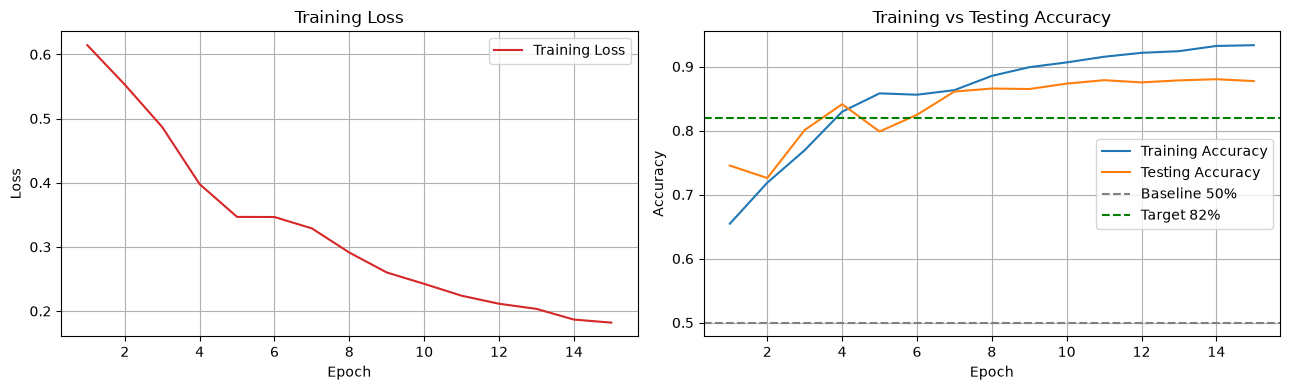

In [117]:
epochs = range(1, len(train_accuracies) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, train_losses, label="Training Loss", color="tab:red")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(epochs, train_accuracies, label="Training Accuracy")
axes[1].plot(epochs, test_accuracies, label="Testing Accuracy")
axes[1].axhline(0.50, linestyle="--", color="gray", label="Baseline 50%")
axes[1].axhline(0.82, linestyle="--", color="green", label="Target 82%")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training vs Testing Accuracy")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

